# Biolek Memristor .sub example
This notebook runs a transient analysis using the `biolek_mmrstor_model.sub` file (no plugin).
SHows how to use Jyce with plugins and creating a circuit and how to run a Xyce simulation.

In [1]:
using Jyce
using Plots
# Constants you can modify for quick experiments
amp = 25.0           # drive amplitude (V)
freq = 250.0         # drive frequency (Hz)
dt = 1e-5            # timestep (s)
tstop = 1e-2         # stop time (s)
xyce_timeout = 10    # seconds (timeout for Xyce)
# Locate the subcircuit file in the notebook folder (minimal search)
candidates = ["biolek_mmrstor_model.sub", joinpath(@__DIR__, "biolek_mmrstor_model.sub")]
subckt = findfirst(isfile, candidates) === nothing ? error("biolek_mmrstor_model.sub not found. Place it next to this notebook.") : abspath(candidates[findfirst(isfile, candidates)])
println("Using subcircuit: ", subckt)

# Initialize Jyce native simulator if available (preferred over manual Xyce path)
try
    Jyce.require_native!()
    sim = try Jyce.XyceSimulator(false) catch e
        @warn "Failed to create Jyce.XyceSimulator: " e
        nothing
    end
    if sim !== nothing
        @info "Jyce native simulator initialized (will prefer this for runs)."
    end
catch e
    @warn "Jyce native integration not available: " e
    sim = nothing
end


Using subcircuit: /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/biolek_mmrstor_model.sub


┌ Info: Jyce native simulator initialized (will prefer this for runs).
└ @ Main /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W1sZmlsZQ==.jl:22


┌ Info: Falling back to system Xyce (timeout 10s)
└ @ Main /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:49



*****
***** Welcome to the Xyce(TM) Parallel Electronic Simulator
*****
***** This is version XyceNF Release 7.10.0
***** Date: Mon May 11 13:32:15 CEST 2026


***** Executing netlist biolek_minimal.cir

***** Reading and parsing netlist...
***** Setting up topology...

***** Device Count Summary ...
       B level 1 (Expression Based Voltage or Current Source) 2
       C level 1 (Capacitor)                                  1
       V level 1 (Independent Voltage Source)                 1
       --------------------------------------------------------
       Total Devices                                          4
***** Setting up matrix structure...
***** Number of Unknowns = 3
***** Initializing...

***** Beginning DC Operating Point Calculation...

***** Beginning Transient Calculation...

***** Percent complete: 1.3 %
***** Current system time: Mon May 11 13:32:15 2026
***** Estimated time to completion:  0 sec.

***** Percent complete: 2.5 %
***** Current system time: Mon May 11 

┌ Info: Reading PRN: 
│   pr = /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/biolek_minimal.cir.prn
└ @ Main /home/daris/Documents/workspace/memristor_proj/mmrstor_biolek/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:60


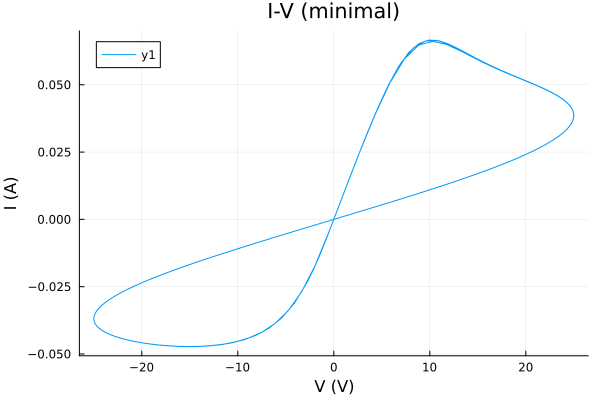

In [2]:
# Minimal netlist, short transient and small output set
plots_dir = @__DIR__
netlist = joinpath(plots_dir, "biolek_minimal.cir")
prn = joinpath(plots_dir, "biolek_minimal.prn")
# use dt, tstop, amp, freq from the constants cell

# Basic Netlist 
net = """
* Minimal Biolek test
.INCLUDE "$(subckt)"
V1 IN 0 SIN(0 $(amp) $(freq))
XMEM IN 0 WPOS MEM_BIOLEK
.TRAN $(dt) $(tstop)
.PRINT TRAN V(IN) I(V1)
.END
"""

open(netlist, "w") do io; write(io, net); end

# Try running via Jyce native simulator if initialized, else fall back to system Xyce
run_via_jyce = false
if isdefined(Main, :sim) && sim !== nothing
    try
        @info "Attempting to run using Jyce native simulator"
        # Try a few common method names safely
        try
            sim.run_netlist(netlist)
            run_via_jyce = true
        catch
            try
                sim.run(netlist)
                run_via_jyce = true
            catch
                try
                    sim.execute(netlist)
                    run_via_jyce = true
                catch e
                    @warn "Jyce simulator run attempts failed: " e
                end
            end
        end
    catch e
        @warn "Error while invoking Jyce simulator: " e
    end
end

if !run_via_jyce
    xyce = Sys.which("Xyce") === nothing ? "/usr/local/XyceNF_7.10/bin/Xyce" : Sys.which("Xyce")
    @info "Falling back to system Xyce (timeout $(xyce_timeout)s)"
    try
      cd(dirname(netlist)) do; run(`timeout $(xyce_timeout)s $(xyce) $(basename(netlist))`); end
    catch e
      @warn "Xyce run failed or timed out: " e
    end
end

# find PRN (simple heuristic)
cands = [prn, joinpath(dirname(netlist), basename(netlist) * ".prn"), joinpath(dirname(netlist), splitext(basename(netlist))[1] * ".prn")]
pr = findfirst(isfile, cands) === nothing ? error("No PRN produced by Xyce. Check Xyce stdout/stderr.") : cands[findfirst(isfile, cands)]
@info "Reading PRN: " pr
df = Jyce.read_simulation_data(pr)
t = Float64.(df[:, Symbol("TIME")])
v = Float64.(df[:, Symbol("V(IN)")])
i = -Float64.(df[:, Symbol("I(V1)")])
plot(v, i; xlabel="V (V)", ylabel="I (A)", title="I-V (minimal)")
